In [1]:
from src.run_app import *
from src.prepare_gam import *
from src.utils import *
import pickle as pkl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import defaultdict
from tqdm import tqdm

In [2]:
# load the dataset
dataset_name = 'compas'
path = 'datasets/{}.csv'.format(dataset_name)
dataset = pd.read_csv(path)
dataset.iloc[:, -1][dataset.iloc[:, -1] == 0] = -1
X, y = dataset.iloc[:, :-1], dataset.iloc[:, -1]

X_one_hot, count = one_hot_encoding(X, one_hot=True)
y = pd.DataFrame(y)  # {0,1}

header = list(X_one_hot.columns)
header = pd.Index(["intercept"] + header)
header = header.astype("object")

# add a column of one to X_orig and make y in {1,-1}
X_one_hot, y = utils.get_X_y(X_one_hot, y)
y = y[:, -1]

print("header dimension", len(header), flush=True)
print(X_one_hot.shape, y.shape)

header dimension 142
(6907, 142) (6907,)


In [ ]:
from FasterRisk.src.fasterrisk import fasterrisk

### example using 3 swaps ###
# rs = fasterrisk.RiskScoreOptimizer(X_one_hot, y, k=10, lb=-100, ub=100, gap_tolerance=0.008, select_top_m=100)
# rs.optimize(generate_non_integer_solution=True, test=True, swaps=3)
# beta0, betas = rs.sparseDiversePool_beta0, rs.sparseDiversePool_betas

# # save betas and beta0 to a pickle file
# with open("compas_0.008_3.pkl", "wb") as f:
#     pkl.dump({"betas": betas, "beta0": beta0}, f)

### example with 2 swaps ###
rs = fasterrisk.RiskScoreOptimizer(X_one_hot, y, k=10, lb=-100, ub=100, gap_tolerance=0.003, select_top_m=100)
rs.optimize(generate_non_integer_solution=True, test=True, swaps=2)
beta0, betas = rs.sparseDiversePool_beta0, rs.sparseDiversePool_betas

### example with 1 swap ###
# rs = fasterrisk.RiskScoreOptimizer(X_one_hot, y, k=10, lb=-100, ub=100, gap_tolerance=0.002, select_top_m=100)
# rs.optimize(generate_non_integer_solution=True, test=True, swaps=1)
# beta0, betas = rs.sparseDiversePool_beta0, rs.sparseDiversePool_betas

In [7]:
print(f"found {betas.shape[0]} models")
mean_loss = 0
for i in range(len(betas)):
    wi = betas[i, :]
    intercepti = beta0[i]
    logit = X_one_hot @ wi + intercepti
    y_pred = np.exp(logit) / (1 + np.exp(logit))
    y_pred = np.where(y_pred > 0.5, 1, -1)
    mean_loss += (y != y_pred).mean()
    print(np.nonzero(wi)[0], (y != y_pred).mean())
print(mean_loss / len(betas))

found 13 models
[  4   5   6   7  41  89 103 104 105 141] 0.33082380194006084
[  4   5   6   7  41  89 103 104 105 140] 0.33082380194006084
[  4   5   6   7  12  89 103 104 105 141] 0.33241638917040683
[  4   5   6   7  12  89 103 104 105 140] 0.33241638917040683
[  4   5   6   7  12  41  89 103 104 105] 0.3300998986535399
[  4   5   6   7   9  41  89 103 104 105] 0.32836253076588967
[  4   5   6   7   9  12  89 103 104 105] 0.3298103373389315
[  2   4   5   6   7  41  89 103 104 105] 0.3290864340524106
[  2   4   5   6   7  12  89 103 104 105] 0.330968582597365
[  2   4   5   6   7   9  89 103 104 105] 0.3292312147097148
[  1   4   5   6   7  41  89 103 104 105] 0.3290864340524106
[  1   4   5   6   7  12  89 103 104 105] 0.330968582597365
[  1   4   5   6   7   9  89 103 104 105] 0.3292312147097148
0.33025581628448286


In [ ]:
# load betas and beta0 from 3 swaps
with open("compas_0.008_3.pkl", "rb") as f:
    data = pkl.load(f)
betas = data["betas"]
beta0 = data["beta0"]

100%|██████████| 37/37 [00:00<00:00, 458.59it/s]


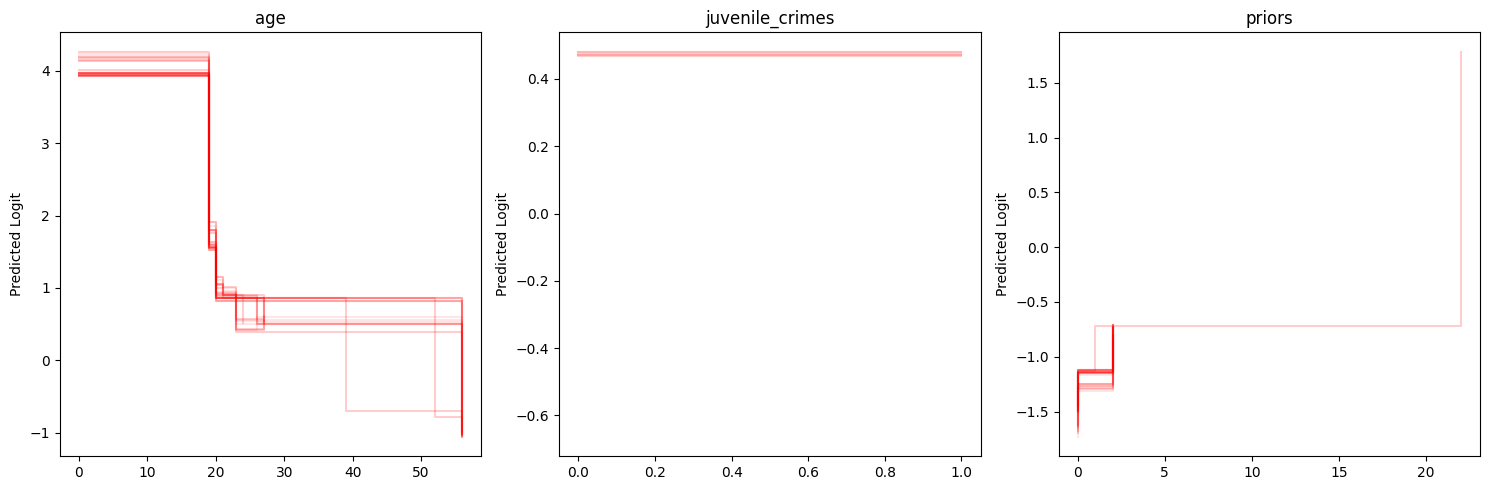

In [9]:
def get_feature_thresholds(weights, columns):
    feature_thresholds = defaultdict(list)
    for col, weight in zip(columns, weights):
        match = re.search(r'([a-zA-Z]+)', col)
        if match:
            feature = match.group(1)
            threshold = re.findall(r'[\d.]+', col)
            if feature == 'juv':
                feature = 'juv_misd_count'
            if feature == 'juvenile':
                feature = 'juvenile_crimes'
            feature_thresholds[feature].append((list(map(float, threshold)), weight))
    return feature_thresholds

def plot_gam(header, list_of_weights):
    rows = 1; cols = 3
    fig, axs = plt.subplots(nrows=rows, ncols=cols, figsize=(5 * cols, 5 * rows))
    axs = axs.flatten()
    ax_dict = {}
    counter = 0
    union_of_support_sets = defaultdict(int)
    for i in tqdm(range(len(list_of_weights))):
        weights = list_of_weights[i, :]
        columns = header[np.nonzero(weights)[0]]
        weights = weights[np.nonzero(weights)[0]]
        for column in columns:
            union_of_support_sets[column] += 1

        feature_thresholds = get_feature_thresholds(weights, columns)
        for feature, thresholds_weights in feature_thresholds.items():
            if feature == 'sex' or feature == 'current':
                continue
            if feature not in ax_dict:
                ax = axs[counter]
                ax_dict[feature] = ax
                counter += 1
            else:
                ax = ax_dict[feature]
            thresholds, feature_weights = zip(*thresholds_weights)

            x_vals, y_vals = [], []
            x_vals.append(0)
            y_vals.append(feature_weights[0])
            for i in range(len(thresholds) - 1):
                x_vals.append(thresholds[i][0])
                y_vals.append(feature_weights[i])

            # For the last value of the interval, add it once more
            x_vals.append(thresholds[-1][-1])
            y_vals.append(feature_weights[-1])

            ax.step(x_vals, y_vals, where="post", color='r', alpha=0.1)
            ax.set_ylabel("Predicted Logit")
            ax.set_title(feature)
    plt.tight_layout()
    plt.show()
    return union_of_support_sets

union_of_support_sets = plot_gam(header, betas[:100, :])

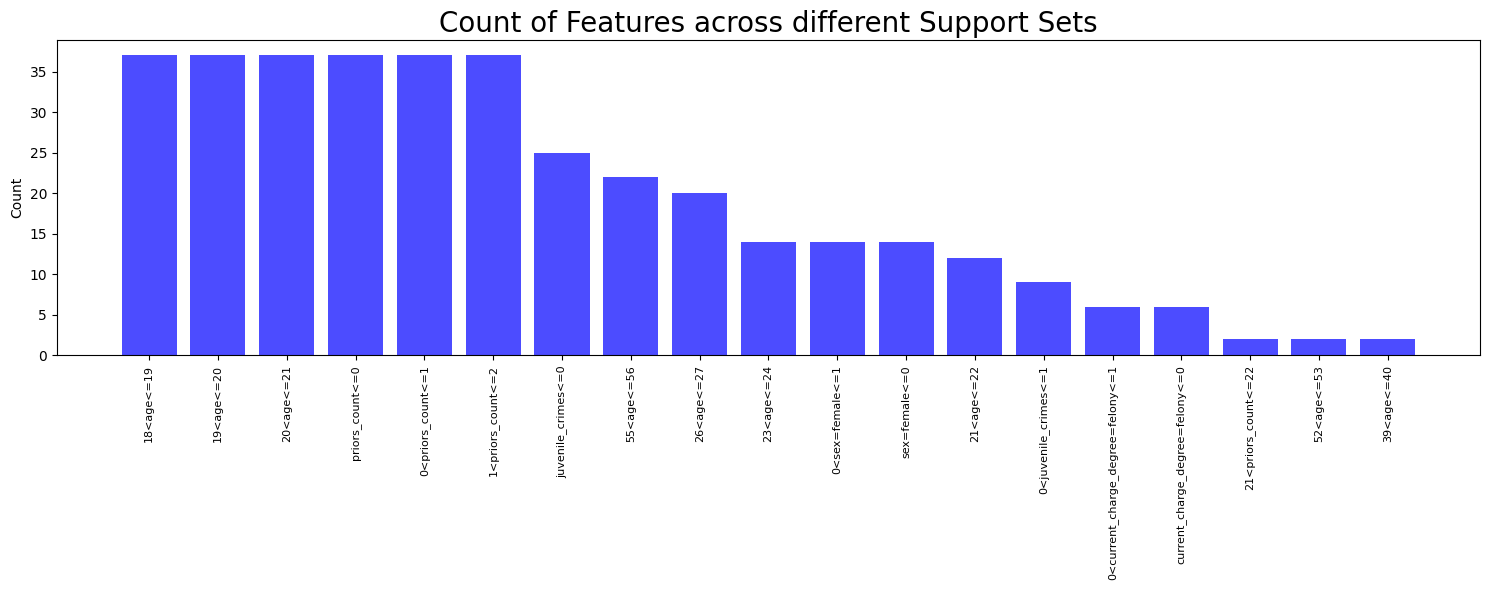

In [10]:
# Given dictionary
sorted_data = dict(sorted(union_of_support_sets.items(), key=lambda x: x[1], reverse=True))

# Prepare data for histogram
keys = list(sorted_data.keys())
values = list(sorted_data.values())

# Plot histogram
plt.figure(figsize=(15, 6))
plt.bar(keys, values, color='blue', alpha=0.7)
plt.xticks(rotation=90, fontsize=8)
plt.ylabel('Count')
plt.title('Count of Features across different Support Sets', fontsize=20)
plt.tight_layout()
plt.show()